# Verify a demonstration

This notebook interactively loads one demonstration and shows how to access its metadata, images, actions, and annotations.

In [1]:
import sys
sys.path.append('..')

import matplotlib.pyplot as plt
import numpy as np
from pprint import pprint

from exp_run_config import Config
from demonstration import Demonstration, select_demo, get_simple_transform

Config.PROJECTNAME = 'BerryPicker'

## Select a demonstration

Set the experiment and run to inspect, then choose one of the demonstrations listed by the selector.

In [2]:
experiment, run = 'demonstration', 'random-both-cameras-video'
exp = Config().get_experiment(experiment, run)

demo_name = select_demo(exp)
demo = Demonstration(exp, demo_name)
print(f'Loaded demonstration: {demo_name}')

***ExpRun**: Loading pointer config file:
	/home/lboloni/.config/BerryPicker/mainsettings.yaml
***ExpRun**: Loading machine-specific config file:
	~/WORK/BerryPicker/cfg/settings.yaml
***ExpRun**: Using torch device: cuda
***ExpRun**: Configuration for exp/run: demonstration/random-both-cameras-video successfully loaded
A pop up dialog will appear now. Enter the number of demonstration.
	0: 2025_03_08__14_19_12
	1: 2025_03_08__14_24_52
	2: 2025_03_08__14_23_19
	3: 2025_03_08__14_27_55
	4: 2025_03_08__14_32_20
	5: 2025_03_08__14_29_07
	6: 2025_03_08__14_21_28
	7: 2025_03_08__14_15_53
	8: 2025_03_08__14_16_57
	9: 2025_03_08__14_26_12
You chose demonstration: 2025_03_08__14_19_12
Loaded demonstration: 2025_03_08__14_19_12


## Read the metadata

Metadata records the camera names, number of timesteps, and whether images are stored as files or video.

In [3]:
pprint(demo.metadata)

{'cameras': ['dev2', 'dev3'],
 'maxsteps': 446,
 'stored_as_images': False,
 'stored_as_video': True}


## Read one timestep

This reads one camera image together with the action and annotation saved for the same timestep. Change `step` or `camera` to inspect another point.

Action:
{'rc-angle-target': {'0': 76.81990028477364,
                     '1': 116.0,
                     '2': 102.0,
                     '3': 67.0,
                     '4': 85.69947097707822},
 'rc-position-target': {'distance': 4.770596886299516,
                        'gripper': 36.586077973696085,
                        'heading': -13.180099715226362,
                        'height': 4.567665395962308,
                        'wrist_angle': -52.562566877280965,
                        'wrist_rotation': 85.69947097707822},
 'rc-pulse-target': {'0': 1393.0,
                     '1': 1748.0,
                     '2': 1633.0,
                     '3': 1244.0,
                     '4': 1452.0,
                     '5': 1951.2088303945588},
 'time': 223}
Annotation:
{'comment': '', 'labels': [], 'reward': 0.0, 'time': 223}


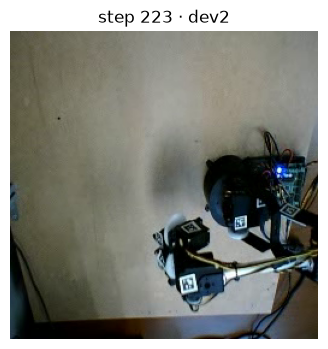

In [4]:
step = demo.metadata['maxsteps'] // 2
camera = demo.metadata['cameras'][0]
transform = get_simple_transform()

sensor, image = demo.get_image(step, camera=camera, transform=transform)
plt.figure(figsize=(5, 4))
plt.imshow(image)
plt.title(f'step {step} · {camera}')
plt.axis('off')

print('Action:')
pprint(demo.actions[step])
print('Annotation:')
pprint(demo.annotations[step])

## Visualize 12 sampled timesteps

Each row is a sampled timestep and each column is a camera. The gallery therefore shows every camera at the same moments, making viewpoints and synchronization easy to inspect.

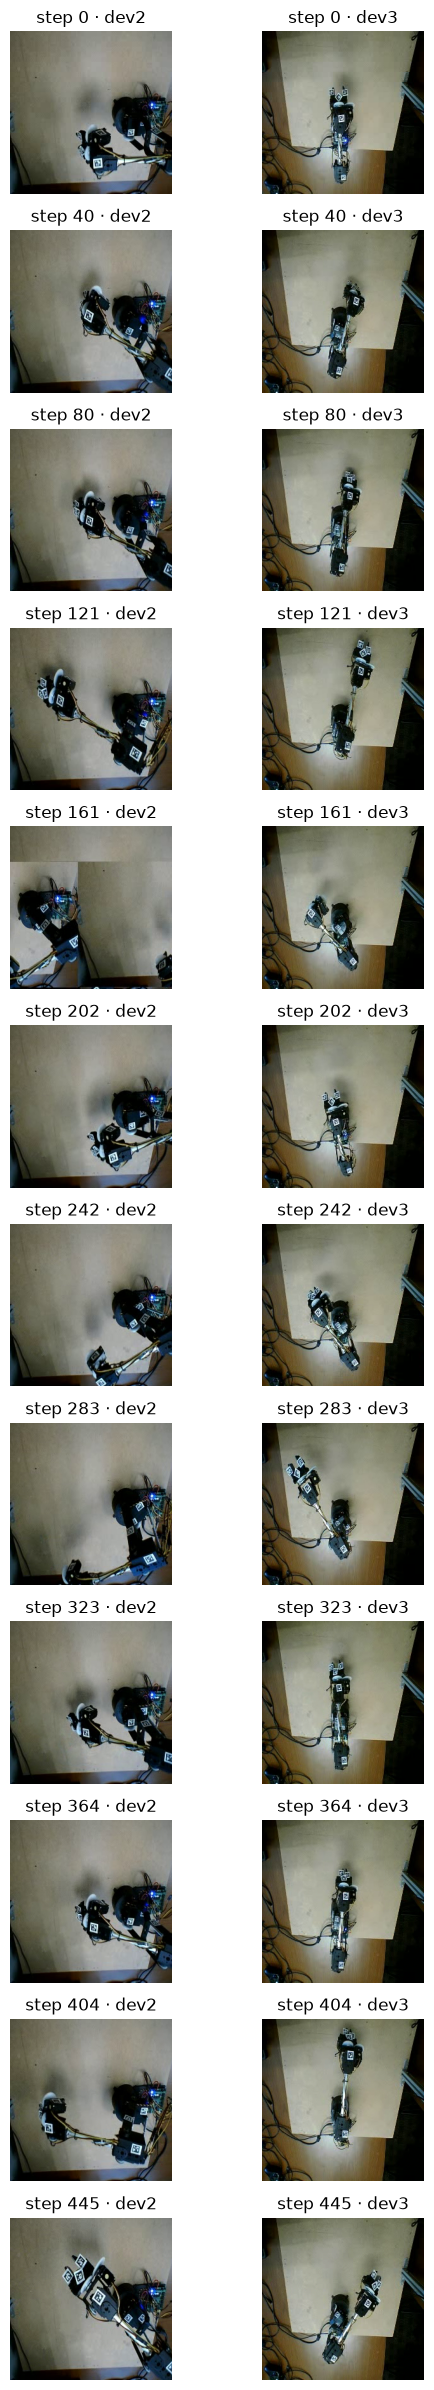

In [5]:
n_samples = 12
cameras = demo.metadata['cameras']
steps = np.linspace(0, demo.metadata['maxsteps'] - 1,
                    min(n_samples, demo.metadata['maxsteps']), dtype=int)

fig, axes = plt.subplots(len(steps), len(cameras), squeeze=False,
                         figsize=(3 * len(cameras), 2 * len(steps)))
for row, step in enumerate(steps):
    for col, camera in enumerate(cameras):
        _, image = demo.get_image(step, camera=camera, transform=transform)
        axes[row, col].imshow(image)
        axes[row, col].set_title(f'step {step} · {camera}')
        axes[row, col].axis('off')
fig.tight_layout()